### Encoder layer diagram

BERT-large encoder layer (x24), redrawn (not copied) following Vaswani et al.
(2017): Q/K/V linear projections per head, scaled dot-product attention,
concat, W_O projection, Add & Norm, FFN, Add & Norm. Input is X from the
embedding layer figure; the final layer's output feeds the fine-tuning head
figure.

Writes `encoder_diagram.png`.

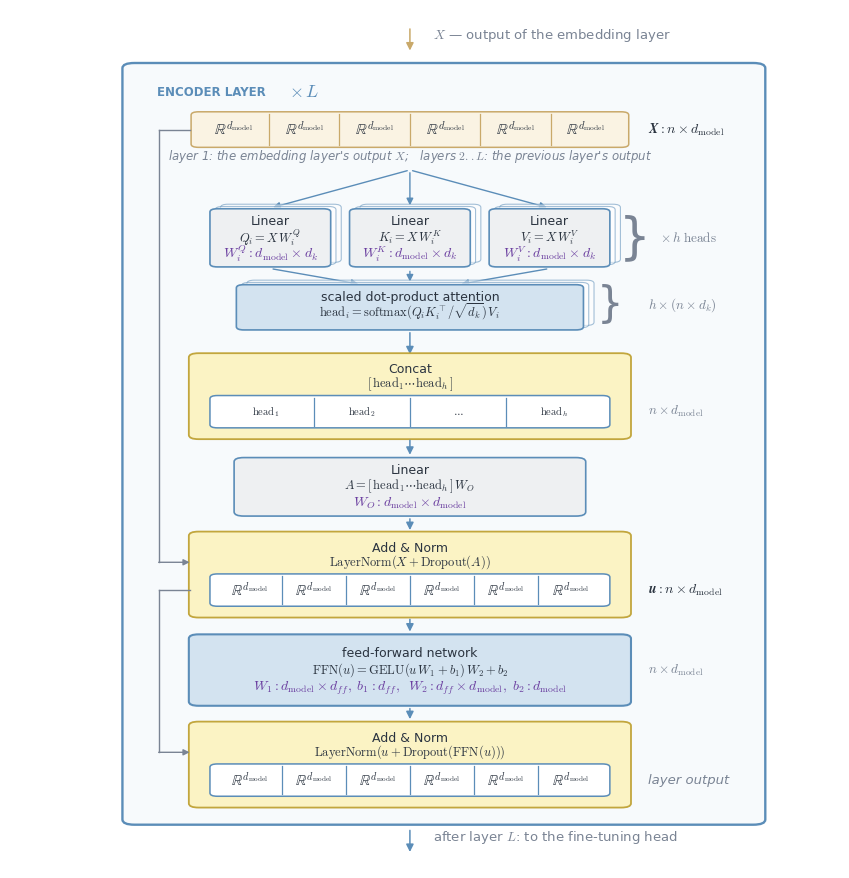

In [1]:
import matplotlib.pyplot as plt

plt.rcParams["mathtext.fontset"] = "cm"
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

INK = "#2b3440"
SAND, SAND_E = "#faf3e3", "#c9a96a"
BLUE_E = "#5b8db8"
BLUED = "#d3e3f0"
YEL, YEL_E = "#fbf3c4", "#c2a63d"
LGREY = "#eef0f2"
GREYT = "#7a8494"
TRAIN = "#6b3fa0"
BLOCKBG = "#f7fafc"

fig, ax = plt.subplots(figsize=(8.6, 8.88))
ax.set_xlim(0, 11.0)
ax.set_ylim(4.5, 31.05)
ax.axis("off")

X, W = 2.5, 5.6
MID = X + W / 2
NX = X + W + 0.35  # left edge of the side-note column, hugging the boxes

MATHR = r"$\mathbb{R}^{d_{\mathrm{model}}}$"
NDIM = r"$n \times d_{\mathrm{model}}$"
DIMH = r"$h \times (n \times d_k)$"
XLBL = r"$\boldsymbol{X}: n \times d_{\mathrm{model}}$"
ULBL = r"$\boldsymbol{u}: n \times d_{\mathrm{model}}$"
XHEADS = r"$\times\,h\; \mathrm{heads}$"
CATEQ = r"$[\,\mathrm{head}_1 \cdots \mathrm{head}_h\,]$"
WOEQ = r"$A = [\,\mathrm{head}_1 \cdots \mathrm{head}_h\,]\,W_O$"
WOTBL = r"$W_O: d_{\mathrm{model}} \times d_{\mathrm{model}}$"
ANEQ1 = r"$\mathrm{LayerNorm}(X + \mathrm{Dropout}(A))$"
ANEQ2 = r"$\mathrm{LayerNorm}(u + \mathrm{Dropout}(\mathrm{FFN}(u)))$"
FFNL = r"$\mathrm{FFN}(u) = \mathrm{GELU}(u\,W_1 + b_1)\,W_2 + b_2$"
FFNTBL = (
    r"$W_1: d_{\mathrm{model}} \times d_{ff},\; b_1: d_{ff},\;\;"
    r"W_2: d_{ff} \times d_{\mathrm{model}},\; b_2: d_{\mathrm{model}}$"
)


def box(x, y, w, h, text, fc, ec, fs=9, lw=1.3):
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            w,
            h,
            boxstyle="round,pad=0.13",
            facecolor=fc,
            edgecolor=ec,
            linewidth=lw,
        )
    )
    if text:
        ax.text(
            x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=INK
        )


def note(y, text, fs=9.5):
    ax.text(MID + 0.3, y, text, fontsize=fs, color=GREYT, ha="left")


def arrow(y0, c=INK, x=None, dy=0.84):
    if x is None:
        x = MID
    ax.add_patch(
        FancyArrowPatch(
            (x, y0), (x, y0 - dy), arrowstyle="-|>", mutation_scale=11, color=c, lw=1.1
        )
    )


def table_row(y, labels, fs=8.2, fc="white", ec=SAND_E, h=0.9, x=None, w=None):
    if x is None:
        x = X
    if w is None:
        w = W
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            w,
            h,
            boxstyle="round,pad=0.10",
            facecolor=fc,
            edgecolor=ec,
            linewidth=1.1,
        )
    )
    n = len(labels)
    for i, t in enumerate(labels):
        if i:
            ax.plot(
                [x + i * w / n, x + i * w / n],
                [y - 0.03, y + h + 0.03],
                color=ec,
                lw=0.9,
            )
        ax.text(
            x + (i + 0.5) * w / n,
            y + h / 2,
            t,
            ha="center",
            va="center",
            fontsize=fs,
            family="DejaVu Sans Mono",
            color=INK,
        )


def stacked(x, y, w, h, text, fc, ec, fs=8.5):
    for off in (0.14, 0.07):
        ax.add_patch(
            FancyBboxPatch(
                (x + off, y + off),
                w,
                h,
                boxstyle="round,pad=0.10",
                facecolor="white",
                edgecolor=ec,
                linewidth=0.8,
                alpha=0.55,
            )
        )
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            w,
            h,
            boxstyle="round,pad=0.10",
            facecolor=fc,
            edgecolor=ec,
            linewidth=1.2,
        )
    )
    if text:
        ax.text(
            x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=INK
        )


# yellow step block: title, equation, resulting shape drawn as a row inside
def yelblock(y, title, eq, cells, cfs):
    box(X, y, W, 2.4, "", YEL, YEL_E)
    ax.text(MID, y + 2.02, title, ha="center", va="center", fontsize=9, color=INK)
    ax.text(MID, y + 1.58, eq, ha="center", va="center", fontsize=9, color=INK)
    table_row(y + 0.32, cells, fs=cfs, ec=BLUE_E, h=0.8, x=X + 0.25, w=W - 0.5)
    return y + 0.72  # centre height of the shape row, for side labels


# entry: X, the embedding layer's output
arrow(30.55, SAND_E)
note(30.15, "$X$ — output of the embedding layer")

# ---- encoder layer (xL)
bx, bw = X - 0.85, W + 2.6
ax.add_patch(
    FancyBboxPatch(
        (bx, 6.0),
        bw,
        23.25,
        boxstyle="round,pad=0.16",
        facecolor=BLOCKBG,
        edgecolor=BLUE_E,
        linewidth=1.7,
    )
)
ax.text(
    bx + 0.3,
    28.5,
    "ENCODER LAYER",
    fontsize=8.5,
    ha="left",
    va="center",
    color=BLUE_E,
    fontweight="bold",
)
ax.text(
    bx + 2.05,
    28.5,
    r"$\times\,L$",
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="center",
    color=BLUE_E,
)

table_row(26.9, [MATHR] * 6, fs=11.0, fc=SAND)
ax.text(NX, 27.35, XLBL, ha="left", va="center", fontsize=10, color=INK)
ax.text(
    MID,
    26.42,
    "layer 1: the embedding layer's output $X$;   layers $2..L$: the previous layer's output",
    fontsize=8.5,
    style="italic",
    color=GREYT,
    ha="center",
)

# fan out to Q, K, V linear projections (grey "Linear" blocks, Vaswani style)
lw3 = 1.4
lxs = [MID - 2.55, MID - lw3 / 2, MID + 1.15]
for lx, lab in zip(lxs, ["Q", "K", "V"]):
    cx = lx + lw3 / 2
    ax.add_patch(
        FancyArrowPatch(
            (MID, 26.1),
            (cx, 24.92),
            arrowstyle="-|>",
            mutation_scale=10,
            color=BLUE_E,
            lw=1.0,
        )
    )
    stacked(lx, 23.20, lw3, 1.60, "", LGREY, BLUE_E)
    ax.text(cx, 24.50, "Linear", ha="center", va="center", fontsize=9, color=INK)
    ax.text(
        cx,
        24.00,
        "$" + lab + r"_i = X\,W_i^{" + lab + "}$",
        ha="center",
        va="center",
        fontsize=9,
        color=INK,
    )
    ax.text(
        cx,
        23.50,
        r"$W_i^{" + lab + r"}: d_{\mathrm{model}} \times d_k$",
        ha="center",
        va="center",
        fontsize=10.0,
        color=TRAIN,
    )
    ax.add_patch(
        FancyArrowPatch(
            (cx, 23.05),
            (MID + (cx - MID) * 0.35, 22.56),
            arrowstyle="-|>",
            mutation_scale=10,
            color=BLUE_E,
            lw=1.0,
        )
    )
# curly brace hugging the stacked Q, K, V projections
ax.text(8.28, 24.0, "}", ha="center", va="center", fontsize=36, color=GREYT)
ax.text(
    8.62,
    24.0,
    XHEADS,
    ha="left",
    va="center",
    fontsize=9.5,
    style="italic",
    color=GREYT,
)

stacked(X + 0.6, 21.25, W - 1.2, 1.2, "", BLUED, BLUE_E)
ax.text(
    MID,
    22.15,
    "scaled dot-product attention",
    ha="center",
    va="center",
    fontsize=9,
    color=INK,
)
ax.text(
    MID,
    21.7,
    r"$\mathrm{head}_i = \mathrm{softmax}(Q_i K_i^{\top} / \sqrt{d_k})\,V_i$",
    ha="center",
    va="center",
    fontsize=9,
    color=INK,
)
# curly brace hugging the stacked heads (Vaswani style)
ax.text(7.95, 21.92, "}", ha="center", va="center", fontsize=30, color=GREYT)
ax.text(
    NX, 21.92, DIMH, ha="left", va="center", fontsize=9.5, style="italic", color=GREYT
)
arrow(21.15, BLUE_E)

# concatenate the h heads
ry = yelblock(
    17.9,
    "Concat",
    CATEQ,
    [r"$\mathrm{head}_1$", r"$\mathrm{head}_2$", r"$\cdots$", r"$\mathrm{head}_h$"],
    7.6,
)
ax.text(NX, ry, NDIM, ha="left", va="center", fontsize=9.5, style="italic", color=GREYT)
arrow(17.82, BLUE_E, dy=0.62)

# W_O projection: one shared linear map, so no per-head shadow
box(X + 0.6, 15.52, W - 1.2, 1.55, "", LGREY, BLUE_E, lw=1.2)
ax.text(MID, 16.80, "Linear", ha="center", va="center", fontsize=9, color=INK)
ax.text(MID, 16.30, WOEQ, ha="center", va="center", fontsize=9, color=INK)
ax.text(MID, 15.80, WOTBL, ha="center", va="center", fontsize=10.0, color=TRAIN)
arrow(15.39, BLUE_E, dy=0.52)

# Add & Norm after W_O; its output row is the state u
ry = yelblock(12.38, "Add & Norm", ANEQ1, [MATHR] * 6, 10.5)
ax.text(NX, ry, ULBL, ha="left", va="center", fontsize=10, color=INK)
arrow(12.28, BLUE_E, dy=0.55)

# Feed-Forward Network
box(X, 9.65, W, 1.95, "", BLUED, BLUE_E, lw=1.5)
ax.text(
    MID, 11.15, "feed-forward network", ha="center", va="center", fontsize=9, color=INK
)
ax.text(MID, 10.63, FFNL, ha="center", va="center", fontsize=9, color=INK)
ax.text(MID, 10.07, FFNTBL, ha="center", va="center", fontsize=10.0, color=TRAIN)
ax.text(
    NX, 10.63, NDIM, ha="left", va="center", fontsize=9.5, style="italic", color=GREYT
)
arrow(9.52, BLUE_E, dy=0.50)

# Add & Norm (FFN residual addition); its output row is the layer output
ry = yelblock(6.5, "Add & Norm", ANEQ2, [MATHR] * 6, 10.5)
ax.text(
    NX,
    ry,
    "layer output",
    ha="left",
    va="center",
    fontsize=9.5,
    style="italic",
    color=GREYT,
)

# Residual Connections
XL = bx + 0.32


def residual(y_from, y_to):
    sx = X - 0.12
    ax.plot([sx, XL], [y_from, y_from], color=GREYT, lw=1.0, zorder=1)
    ax.plot([XL, XL], [y_from, y_to], color=GREYT, lw=1.0, zorder=1)
    ax.add_patch(
        FancyArrowPatch(
            (XL, y_to),
            (sx, y_to),
            arrowstyle="-|>",
            mutation_scale=9,
            color=GREYT,
            lw=1.0,
            shrinkA=0,
            shrinkB=0,
        )
    )


residual(27.35, 13.96)  # From X down to Add & Norm (LayerNorm(X + Dropout(A)))
residual(
    13.10, 8.08
)  # From the u row down to Add & Norm (LayerNorm(u + Dropout(FFN(u))))

# exit: after layer L, the token vectors go to the fine-tuning head
arrow(5.75, BLUE_E)
note(5.35, "after layer $L$: to the fine-tuning head")

fig.tight_layout()
fig.savefig("encoder_diagram.png", dpi=200, bbox_inches="tight", facecolor="white")
fig.savefig("encoder_diagram.pdf", bbox_inches="tight", facecolor="white")